# Running computations in parallel on gridded data with Xarray and Dask

Xarray makes working with labelled multi-dimensional arrays in Python simple, efficient, and fun!

Use Dask and Xarray to churn through terabytes of multi-dimensional array data in formats like HDF, NetCDF, TIFF, or Zarr.  

In [1]:
import os
from pathlib import Path

from distributed import LocalCluster
import dask
import cartopy.crs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr.codecs

Helper function for plotting data on a map

In [2]:
def plot_map(da: xr.DataArray, projection=cartopy.crs.Robinson()) -> None:
    """Create a map plot."""
    plt.figure(figsize=[12,8])
    p = da.plot(
        subplot_kws={
            "projection": projection,
        },
        add_colorbar=False,
        transform=cartopy.crs.PlateCarree(),
    )
    plt.colorbar(p, shrink=0.6)
    p.axes.set_global()
    p.axes.coastlines()

## Explore the tutorial data

We will use the xarray tutorial data, a small dataset that xarray can automatically download. When loading large data with xarray, the `chunks` keyword argument should be provided to ensure data is not loaded into memory. Specifying `chunks={}` will load the data with chunks as they are on disk. This is useful for inspection, but should generally not be used for computations as the chunks on disk are typically of the order of a few megabytes, while a good chunks size for computations with Dask is about 100 megabyte. The `chunks="auto"` option will automatically choose a good chunk size for running computations with Dask, while aligning the Dask chunks with the chunks on Disk for efficient reading.

In [3]:
ds = xr.tutorial.open_dataset("air_temperature", chunks="auto")
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB dask.array<chunksize=(2920, 25, 53), meta=np.ndarray>
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

We see that it is a three dimensional dataset of air temperature. The data has been interpreted as a single Dask chunk because it is so small.

In [4]:
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53)> Size: 31MB
dask.array<open_dataset-air, shape=(2920, 25, 53), dtype=float64, chunksize=(2920, 25, 53), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

Let's plot the first time point of the data to get an idea of what we are working with:

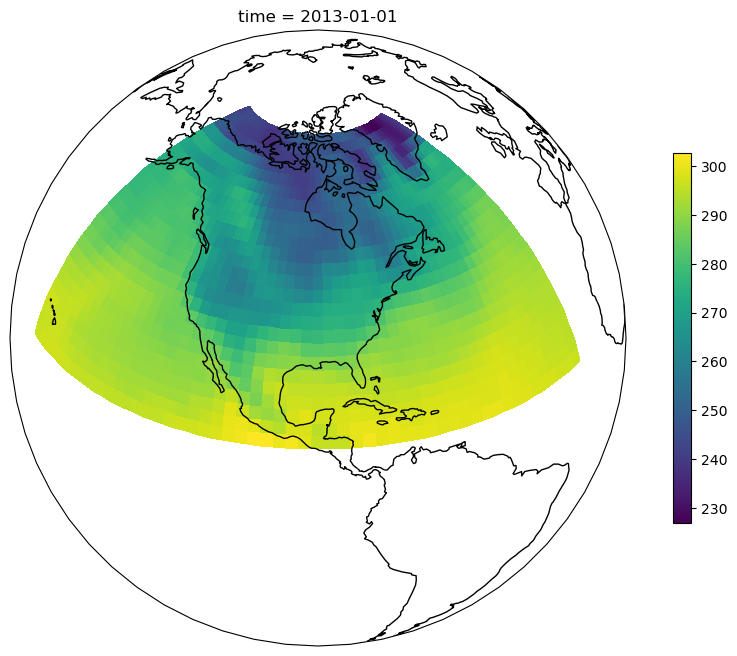

In [5]:
north_america = cartopy.crs.Orthographic(-90, 35)
plot_map(ds.air.isel(time=0), projection=north_america)

So, this datasets is air temperature over North America from 2013 and 2014 at four time points a day.

## Prepare the tutorial data

We will increase the spatial resolution of the tutorial dataset to make the computation that we are going to perform more interesting and then save to to zarr format.

In [6]:
scale_factor = 30
ds = xr.tutorial.open_dataset(
    "air_temperature",
    chunks={"time": 30}  # We choose the input chunks here such the resulting high-resolution dataset has reasonably sized (~100 MB) chunks.
)
ds = ds.interp(
    lat=np.linspace(ds.lat.data[0], ds.lat.data[-1], len(ds.lat) * scale_factor),
    lon=np.linspace(ds.lon.data[0], ds.lon.data[-1], len(ds.lon) * scale_factor),
    method="linear",
)
ds["air"] = ds.air.astype("float32")
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 750, lon: 1590)> Size: 14GB
dask.array<astype, shape=(2920, 750, 1590), dtype=float32, chunksize=(30, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

Let's plot the data again to see that it is now much higher resolution:

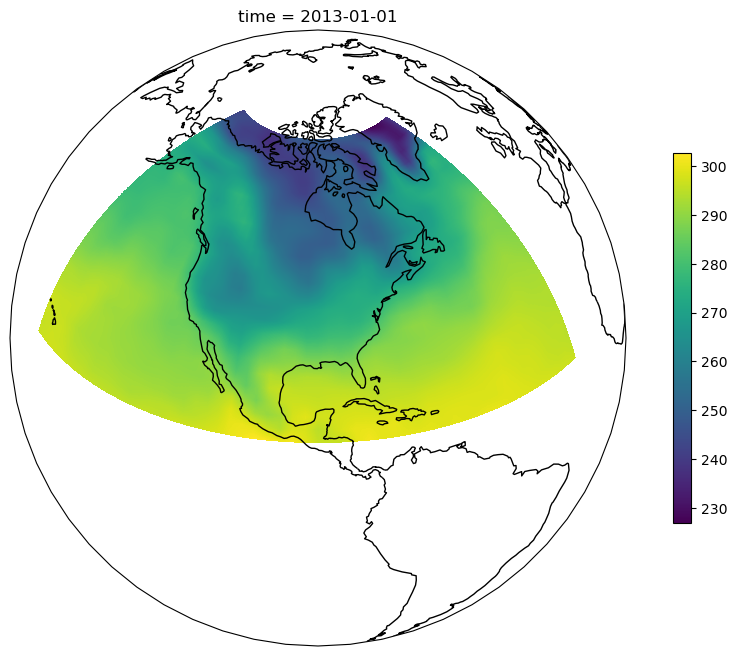

In [7]:
plot_map(ds.air.isel(time=0), projection=north_america)

Let's save the data to disk for usage in the remainder of the tutorial. We use chunks of the order of a megabyte for saving to disk.

In [8]:
# If you do not know how the data is going to be read when saving the file,
# a reasonable choice my be to chunk along all dimensions.
n_splits = 20
zarr_chunks = {
    d: int(s/n_splits)
    for d, s in ds.sizes.items()
}
zarr_chunks

{'time': 146, 'lat': 37, 'lon': 79}

In [9]:
# In this tutorial we will apply some temporal operations, so we will
# split up the data along the time axis only.
zarr_chunks = {"time": 1, "lat": None, "lon": None}

In [10]:
ds.chunk(zarr_chunks).air

<xarray.DataArray 'air' (time: 2920, lat: 750, lon: 1590)> Size: 14GB
dask.array<rechunk-merge, shape=(2920, 750, 1590), dtype=float32, chunksize=(1, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

In [11]:
compressor = zarr.codecs.BloscCodec(
    cname="zstd",
    clevel=4,
    shuffle=zarr.codecs.BloscShuffle.shuffle
)
ds.chunk(zarr_chunks).to_zarr(
    "tutorial.zarr",
    mode="w",
    encoding={v: {"compressors": compressor} for v in ds.data_vars}
);

/home/bandela/src/bouweandela/parallel-python-xarray-dask-example/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [12]:
chunksizes = (1, len(ds.lat), len(ds.lon))
chunksizes

(1, 750, 1590)

In [13]:
ds = xr.open_zarr(
    "tutorial.zarr",
    chunks="auto",
)
ds.to_netcdf(
    "tutorial.nc",
    engine="netcdf4",
    mode="w",
    encoding={v: {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": chunksizes} for v in ds.data_vars},
)

## Running computations in parallel

The example computation we will use in this tutorial is a computation that is commonly used in climate science: we compute the average monthly temperature. This is called a "climatology".

In [14]:
ds = xr.open_zarr(
    "tutorial.zarr",
    chunks="auto",
)
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 750, lon: 1590)> Size: 14GB
dask.array<open_dataset-air, shape=(2920, 750, 1590), dtype=float32, chunksize=(28, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16000366210938, 322.1000061035156]

We can also do the same experiments with a NetCDF dataset:

In [15]:
# ds = xr.open_dataset(
#     "tutorial.nc",
#     chunks="auto",
# )
# ds.air

In [16]:
climatology = ds.groupby("time.month").mean("time")
climatology.air

<xarray.DataArray 'air' (month: 12, lat: 750, lon: 1590)> Size: 57MB
dask.array<transpose, shape=(12, 750, 1590), dtype=float32, chunksize=(1, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16000366210938, 322.1000061035156]

### Compute with the threaded scheduler

Recommended if all these conditions are true:
- the computation has a small task graph
- the computation has a simple task graph
- the computation should be run on a single computer

In [17]:
# Run the computation on a single CPU core.
with dask.config.set({"scheduler": "threads", "num_workers": 1}):
    %time climatology.air.compute();

CPU times: user 39.4 s, sys: 12.9 s, total: 52.3 s
Wall time: 41.5 s


In [18]:
# Run the computation in parallel on two CPU cores and notice it is faster.
with dask.config.set({"scheduler": "threads", "num_workers": 2}):
    %time climatology.air.compute();

CPU times: user 43.5 s, sys: 15.3 s, total: 58.7 s
Wall time: 24.5 s


In [19]:
# Run the computation in parallel on four CPU cores. It is slightly faster still than two CPU cores, but not nearly two times as fast.
with dask.config.set({"scheduler": "threads", "num_workers": 4}):
    %time climatology.air.compute();

CPU times: user 56.9 s, sys: 20.2 s, total: 1min 17s
Wall time: 18.5 s


### Compute with the distributed scheduler

Recommended if any of these conditions is true:
- the computation has a large task graph
- the computation has a complex task graph
- the data is read using a library that does not support multiple threads (HDF5, NetCDF, ..)
- the computation should be run on multiple computers

In [20]:
cluster = LocalCluster(
    n_workers=3,
    threads_per_worker=2,
    memory_limit="2.5GiB",  # per worker
)
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 3
Total threads: 6,Total memory: 7.50 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41593,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46097,Total threads: 2
Dashboard: http://127.0.0.1:35911/status,Memory: 2.50 GiB
Nanny: tcp://127.0.0.1:35807,


In [21]:
%time climatology.air.compute();

2026-05-04 13:51:29,074 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 1.93 GiB -- Worker memory limit: 2.50 GiB
2026-05-04 13:51:29,790 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 1.94 GiB -- Worker memory limit: 2.50 GiB
2026-05-04 13:51:30,601 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

CPU times: user 1.27 s, sys: 342 ms, total: 1.61 s
Wall time: 16.5 s


In [22]:
client.shutdown()

### Why is the computation slow

Use a profiler to find out why the computation is slow.

In [23]:
from pathlib import Path

Path("program.py").write_text(
"""
import dask.config
import xarray as xr

def main() -> None:
    ds = xr.open_zarr(
        "tutorial.zarr",
        chunks="auto",
    )
    climatology = ds.groupby("time.month").mean("time")
    with dask.config.set({"scheduler": "threads", "num_workers": 4}):
        climatology.air.compute();

if __name__ == "__main__":
    main()   
    """
)
!py-spy record --format speedscope --output profile.json -- python program.py

py-spy> Sampling process 100 times a second. Press Control-C to exit.


py-spy> Stopped sampling because process exited
py-spy> Wrote speedscope file to 'profile.json'. Samples: 13171 Errors: 0
py-spy> Visit https://www.speedscope.app/ to view


### Bonus material: other Xarray backends for reading NetCDF data

Xarray supports various readers for NetCDF. We saw that NetCDF appears to be slower than zarr, so if your input data comes as NetCDF or HDF5 files, it may be tempting to try these.

#### Virtual zarr

By storing the indexes of where data is in the NetCDF files, virtual zarr files can be created that can be used to read the file with the zarr library, thus bypassing the single-threaded NetCDF and HDF5 libraries. See the [VirtualiZarr](https://virtualizarr.readthedocs.io) package for more information.

In [24]:
# Copied from https://virtualizarr.readthedocs.io/en/stable/usage.html#__tabbed_1_7
import xarray as xr
from obstore.store import LocalStore
from obspec_utils.registry import ObjectStoreRegistry

from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser

from pathlib import Path

store_path = Path.cwd()
file_path = str(store_path / "tutorial.nc")
file_url = f"file://{file_path}"

store = LocalStore(prefix=store_path)
registry = ObjectStoreRegistry({file_url: store})
parser = HDFParser()
with open_virtual_dataset(
      url=file_url,
      parser=parser,
      registry=registry,
    ) as vds:
    vds.vz.to_kerchunk('tutorial.json', format='json')

/home/bandela/src/bouweandela/parallel-python-xarray-dask-example/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


The dataset can be loaded from the virtual zarr file with

In [25]:
ds = xr.open_dataset(
    'tutorial.json',
    engine="kerchunk",
    chunks="auto",
)
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 750, lon: 1590)> Size: 14GB
dask.array<open_dataset-air, shape=(2920, 750, 1590), dtype=float32, chunksize=(28, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16000366210938, 322.1000061035156]

Running the experiments above with this dataset seems to suggest that virtual zarr parallizes better on the threaded scheduler, but does not work so well with the distributed scheduler.

#### h5py

[h5py](https://github.com/h5netcdf/h5netcdf) is a library for reading and writing NetCDF files without using the NetCDF libraries and supported by Xarray as a backend. h5py also supports the [pyfive](https://github.com/NCAS-CMS/pyfive) library as its own backend, which is a pure Python implementation so should not be limited by the single-threaded implementation of the HDF5 library. The h5py backend can be specified using the environment variable `H5NETCDF_READ_BACKEND`.

In [26]:
os.environ["H5NETCDF_READ_BACKEND"] = "h5py"
ds = xr.open_dataset(
    "tutorial.nc",
    engine="h5netcdf",
    chunks="auto",
)
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 750, lon: 1590)> Size: 14GB
dask.array<open_dataset-air, shape=(2920, 750, 1590), dtype=float32, chunksize=(28, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16000366 322.1000061 ]

Running the experiments above with this dataset seems to suggest that just using h5py instead of netCDF4 does not offer any improvement in parallism. This is expected because the HDF5 library does not support multiple threads.

In [27]:
# Disable the lock because we are not using a library that is not thread-safe.
from xarray.backends.locks import DummyLock

os.environ["H5NETCDF_READ_BACKEND"] = "pyfive"
ds = xr.open_dataset(
    "tutorial.nc",
    engine="h5netcdf",
    chunks="auto",
    lock=DummyLock(),
)
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 750, lon: 1590)> Size: 14GB
dask.array<open_dataset-air, shape=(2920, 750, 1590), dtype=float32, chunksize=(28, 750, 1590), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 3kB 75.0 74.92 74.84 74.76 ... 15.24 15.16 15.08 15.0
  * lon      (lon) float32 6kB 200.0 200.1 200.2 200.2 ... 329.8 329.9 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    var_desc:      Air temperature
    actual_range:  [185.16000366 322.1000061 ]
    GRIB_id:       11
    precision:     2
    dataset:       NMC Reanalysis
    GRIB_name:     TMP
    units:         degK
    parent_stat:   Other
    level_desc:    Surface
    statistic:     Individual Obs

Running the experiments above with this dataset seems to suggest that parallism is better on the threaded scheduler, but the code crashed when trying to use the distributed scheduler.

## Bonus material: ERA5 data

If you would like to run the computation above on some real data, you can take a look at the ERA5 data. ERA5 is a popular reanalysis dataset. A reanalysis dataset is produced by a weather or climate model that is contiously fed with observational data to make it match reality as closely as possible, thus combinging many different observations and filling in gaps. We use a version that has been reformatted by Google into an Analysis Ready Cloud Optimized (ARCO) format because it is much easier to work with.

In [28]:
# Data description at: https://github.com/google-research/arco-era5
era5 = xr.open_zarr(
    "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
    chunks=None,
    storage_options={"token": "anon"},
)
era5

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * time                                                             (time) datetime64[ns] 11MB ...
  * latitude                                                         (latitude) float32 3kB ...
  * longitude                                                        (longitude) float32 6kB ...
  * level                                                            (level) int64 296B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2026-05-04 03:33:25.694095+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-04-28

Note that the dataset contains many different variables. We will load only the temperature at 2 meter height:

In [29]:
variable = "2m_temperature"
da = xr.open_zarr(
    "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
    drop_variables=[v for v in era5.data_vars if v != variable],
    chunks={},
    storage_options={"token": "anon"},
)[variable]
da

<xarray.DataArray '2m_temperature' (time: 1323648, latitude: 721,
                                    longitude: 1440)> Size: 5TB
dask.array<open_dataset-2m_temperature, shape=(1323648, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 11MB 1900-01-01 ... 2050-12-31T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

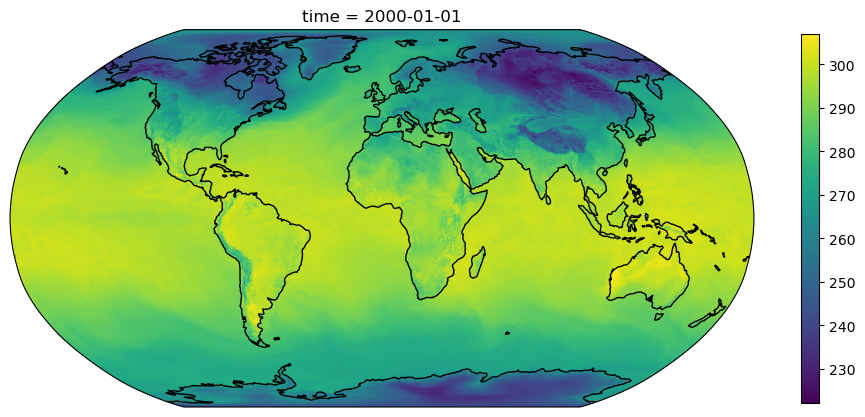

In [30]:
plot_map(da.sel(time="2000-01-01 00:00:00"))

If you are not running this notebook in the Google cloud (e.g. https://colab.research.google.com), it is probably most convenient to download a part of the dataset above and save it locally for further analysis, as this avoids downloading the same data over and over again.

In [31]:
subset = da.loc["2000-01-01":"2000-01-02"]
subset

<xarray.DataArray '2m_temperature' (time: 48, latitude: 721, longitude: 1440)> Size: 199MB
dask.array<getitem, shape=(48, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 384B 2000-01-01 ... 2000-01-02T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

In [32]:
subset.encoding

{'chunks': (1, 721, 1440),
 'preferred_chunks': {'time': 1, 'latitude': 721, 'longitude': 1440},
 'compressors': (Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0),),
 'filters': (),
 'shards': None,
 '_FillValue': np.float32(nan),
 'dtype': dtype('<f4')}

In [33]:
from zarr.codecs.numcodecs import Blosc

In [34]:
da.to_zarr(
    "era5_2m_temperature.zarr",
    mode="w",
)

TypeError: Expected a BytesBytesCodec. Got <class 'numcodecs.blosc.Blosc'> instead.